<a href="https://colab.research.google.com/github/umslengineering/EENG1108/blob/main/week4lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install matplotlib numpy

In [2]:
# SimpleGraphics.py
""" A module that supports the simple drawing of colored
rectangles, disks, stars, line segments, and text. """

import matplotlib.pyplot as plt
import numpy as np
from time import sleep as pause

# Built-in SimpleGraphics colors
YELLOW    = [1.0, 1.0, 0.0]
CYAN      = [0.0, 1.0, 1.0]
MAGENTA   = [1.0, 0.0, 1.0]
RED       = [1.0, 0.0, 0.0]
GREEN     = [0.0, 1.0, 0.0]
BLUE      = [0.0, 0.0, 1.0]
WHITE     = [1.0, 1.0, 1.0]
BLACK     = [0.0, 0.0, 0.0]
PURPLE    = [0.57, 0.17, 0.93]
DARKGRAY  = [0.33, 0.33, 0.33]
LIGHTGRAY = [0.67, 0.67, 0.67]
ORANGE    = [1.0, 0.50, 0.0]
PINK      = [1.0, 0.71, 0.80]


def MakeWindow(M, labels=True, bgcolor=WHITE):
    """
    Creates a window with x range -M<=x<=M and y range -M<=y<=M
    """
    M = int(M)

    plt.figure(figsize=(8, 8), dpi=80)

    ticks = np.linspace(-M, M, 2 * M + 1)
    plt.xticks(ticks)
    plt.yticks(ticks)

    plt.xlim(-M, M)
    plt.ylim(-M, M)

    axes = plt.gca()
    axes.set_facecolor(bgcolor)  # <-- Fixed here for modern matplotlib

    if not labels:
        axes.set_xticks([])
        axes.set_yticks([])

    axes.set_aspect('equal', adjustable='box')


def ShowWindow(duration=None):
    """
    Display the current window.
    """
    if duration is None:
        plt.show()
    else:
        plt.show(block=False)
        pause(duration)


def CloseWindow():
    """ Close all windows. """
    plt.close('all')


def DrawRect(a, b, L, W, theta=0.0, FillColor=None,
             EdgeColor=BLACK, EdgeWidth=1):

    L = float(L)
    W = float(W)
    theta = np.deg2rad(theta)

    x0 = np.array([-L/2, L/2, L/2, -L/2, -L/2])
    y0 = np.array([-W/2, -W/2, W/2, W/2, -W/2])

    x = a + np.cos(theta) * x0 - np.sin(theta) * y0
    y = b + np.sin(theta) * x0 + np.cos(theta) * y0

    if FillColor is None:
        plt.plot(x, y, color=EdgeColor, linewidth=EdgeWidth)
    else:
        plt.fill(x, y, facecolor=FillColor,
                 edgecolor=EdgeColor, linewidth=EdgeWidth)


def DrawDisk(a, b, r, FillColor=None, EdgeColor=BLACK, EdgeWidth=1):

    # (a,b) is the center of the circle
    # r is the radius of the circle

    theta = np.linspace(0, 2 * np.pi, 256)
    x = a + r * np.cos(theta)
    y = b + r * np.sin(theta)

    if FillColor is None:
        plt.plot(x, y, color=EdgeColor, linewidth=EdgeWidth)
    else:
        plt.fill(x, y, facecolor=FillColor,
                 edgecolor=EdgeColor, linewidth=EdgeWidth)


def DrawStar(a, b, r, theta=0.0, FillColor=None,
             EdgeColor=BLACK, EdgeWidth=1):
    # (a,b) is the center point of the 5 pointed star
    # r is the outer radius of the star

    # r2 is the radius of the five inner star corners
    r2 = r* np.sin(np.deg2rad(18))/np.sin(np.deg2rad(126))

    tau = np.linspace(0, 2 * np.pi, 11) + np.pi / 2 + np.deg2rad(theta)
    # tau = np.linspace(0, 2 * np.pi, 11) + np.pi / 10 + np.deg2rad(theta)

    x = np.cos(tau)
    y = np.sin(tau)

    x[0::2] *= r
    y[0::2] *= r
    # 0::2 means the indices 0,2,4,6, ... are the even-indexed points
    # even numbers point multiply by the outer radius r represents the 5 outer
    # star points with radius r

    x[1::2] *= r2
    y[1::2] *= r2
    # 1::2 means the indices 1,3,5,7, ... are the odd-indexed points
    # odd numbers points mulitply by the inner radius r2 represents the 5 corners
    # which are the 5 points close to the center of the star

    x += a
    y += b

    if FillColor is None:
        plt.plot(x, y, color=EdgeColor, linewidth=EdgeWidth)
    else:
        plt.fill(x, y, facecolor=FillColor,
                 edgecolor=EdgeColor, linewidth=EdgeWidth)


def DrawLineSeg(x0, y0, x1, y1, LineColor=BLACK, LineWidth=1):
    plt.plot([x0, x1], [y0, y1],
             color=LineColor, linewidth=LineWidth)


def DrawText(x, y, s, FontColor=BLACK, FontSize=10):
    plt.text(x, y, s, color=FontColor, fontsize=FontSize)


def Title(s, FontColor=BLACK, FontSize=18):
    plt.title(s, fontsize=FontSize, color=FontColor)


def DrawPoly(x, y, FillColor=None, EdgeWidth=1, EdgeColor=BLACK):
    # to draw the triangle x=[0, 2, 1] y=[0, 0, 2]

    u = list(x) + [x[0]] # u = [0, 2, 1, 0]
    v = list(y) + [y[0]] # v = [0, 0, 2, 0]

    if FillColor is None:
        plt.plot(u, v, linewidth=EdgeWidth, color=EdgeColor)
    else:
        plt.fill(u, v, facecolor=FillColor,
                 edgecolor=EdgeColor, linewidth=EdgeWidth)

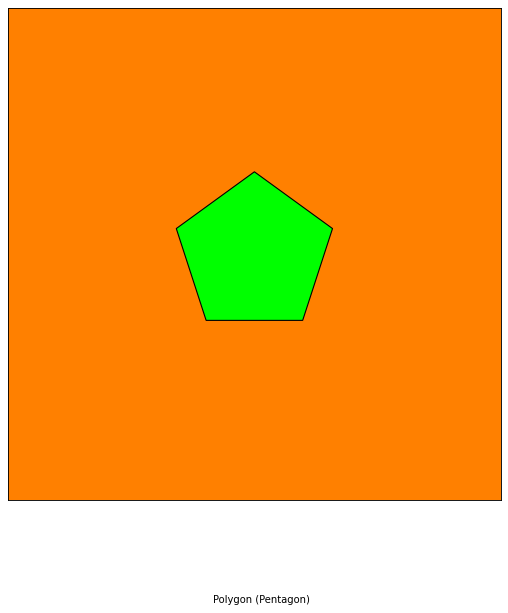

In [10]:

# test program

# from SimpleGraphics import *
import math

if __name__ == '__main__':
    MakeWindow(6, labels=False, bgcolor=ORANGE)

    px, py = [], []
    for k in range(5):
        angle = math.radians(90 + k * 72)
        px.append(2 * math.cos(angle))
        py.append(2 * math.sin(angle))
    DrawPoly(px, py, FillColor=GREEN)
    DrawText(-1, -8.5, "Polygon (Pentagon)", FontSize=9)

    ShowWindow()
    CloseWindow()

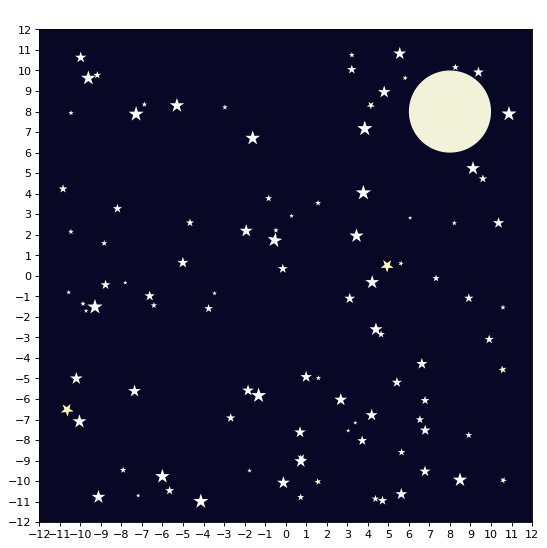

In [14]:
import random
def part2_starry_night():
    M = 12
    MakeWindow(M, bgcolor=[0.03, 0.03, 0.15])
    Title("Part 2: Starry Night", FontColor=WHITE)

    num_stars = 100
    for _ in range(num_stars):
        x = random.uniform(-M + 1, M - 1)
        y = random.uniform(-M + 1, M - 1)
        r = random.uniform(0.1, 0.4)
        twinkle = random.random() < 0.2

        if twinkle:
            color = [1.0, 1.0, random.uniform(0.7, 1.0)]  # pale yellow-white
            angle = random.uniform(0, 360)
        else:
            color = WHITE
            angle = 0.0

        DrawStar(x, y, r, theta=angle, FillColor=color, EdgeWidth=0)

    # Moon drawn last so it sits on top of any stars behind it
    DrawDisk(M - 4, M - 4, 2, FillColor=[0.95, 0.95, 0.85], EdgeWidth=0)

    ShowWindow()

# ---------------------------------------------------------------------------
if __name__ == "__main__":
    part2_starry_night()

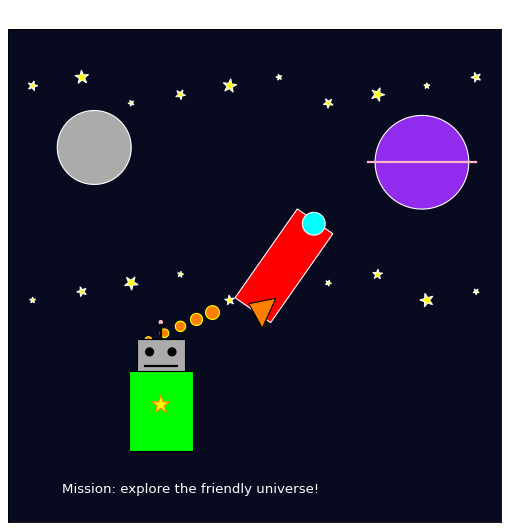

In [4]:
"""Completed solution for Simple Graphics: Python Art Lab."""
# from SimpleGraphics import *


def robot(x, y, scale=1, body_color=CYAN):
    """Draw a robot whose feet are near (x, y)."""
    DrawRect(x, y + 2 * scale, 4 * scale, 5 * scale, FillColor=body_color)
    DrawRect(x, y + 5.5 * scale, 3 * scale, 2 * scale, FillColor=LIGHTGRAY)
    DrawDisk(x - .7 * scale, y + 5.7 * scale, .25 * scale, FillColor=BLACK)
    DrawDisk(x + .7 * scale, y + 5.7 * scale, .25 * scale, FillColor=BLACK)
    DrawLineSeg(x - scale, y + 4.8 * scale, x + scale, y + 4.8 * scale, LineWidth=2)
    # Solution to TODO 1: antenna.
    DrawLineSeg(x, y + 6.5 * scale, x, y + 7.4 * scale, LineWidth=2)
    DrawDisk(x, y + 7.55 * scale, .18 * scale, FillColor=PINK)
    # Solution to TODO 2: badge.
    DrawStar(x, y + 2.4 * scale, .6 * scale, FillColor=YELLOW, EdgeColor=ORANGE)


def rocket(x, y, scale=1):
    """Draw a small rocket pointing diagonally up and right."""
    DrawRect(x, y, 1.6 * scale, 4 * scale, theta=-35, FillColor=RED, EdgeColor=WHITE)
    DrawDisk(x + 1.1 * scale, y + 1.55 * scale, .42 * scale, FillColor=CYAN, EdgeColor=WHITE)
    DrawPoly([x - 1.3 * scale, x - .3 * scale, x - .8 * scale],
             [y - 1.4 * scale, y - 1.2 * scale, y - 2.3 * scale], FillColor=ORANGE)


def final_scene():
    MakeWindow(10, labels=False, bgcolor=[.03, .04, .12])

    # The loop creates a field of stars with changing positions and sizes.
    for i in range(20):
        x = -9 + (i % 10) * 2
        y = -1 + (i // 10) * 8 + (i % 4) * .35
        DrawStar(x, y, .13 + (i % 3) * .08, theta=i * 20,
                 FillColor=YELLOW, EdgeColor=WHITE)

    # Moon and distant planet.
    DrawDisk(-6.5, 5.2, 1.5, FillColor=LIGHTGRAY, EdgeColor=WHITE)
    DrawDisk(6.8, 4.6, 1.9, FillColor=PURPLE, EdgeColor=WHITE)
    DrawLineSeg(4.6, 4.6, 9, 4.6, LineColor=PINK, LineWidth=2)

    # Flight trail and our hero.
    for i in range(5):
        DrawDisk(-1.7 - i * .65, -1.5 - i * .28, .28 - i * .035,
                 FillColor=ORANGE, EdgeColor=YELLOW)
    rocket(1.2, .4, 1.1)
    robot(-3.8, -6.8, scale=.65, body_color=GREEN)
    DrawText(-7.8, -8.8, "Mission: explore the friendly universe!", FontColor=WHITE, FontSize=12)
    Title("The Robot's First Night Flight", FontColor=WHITE)
    ShowWindow()


if __name__ == "__main__":
    final_scene()
